# Etapa 2 — Análise Exploratória de Dados (EDA)
## Cozinha Consciente — Sistema de Recomendação Híbrido de Receitas

Base: **Food.com Recipes and Interactions** (Kaggle)

Este notebook explora a base bruta (`RAW_recipes.csv` e `RAW_interactions.csv`)

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_preparation import load_raw, prepare_recipes, prepare_interactions

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (7, 4)

## 1. Carregamento dos dados brutos

In [2]:
raw_recipes, raw_interactions = load_raw()

print("Receitas:", raw_recipes.shape)
print("Interações:", raw_interactions.shape)
raw_recipes.head(3)

Receitas: (231637, 12)
Interações: (1132367, 5)


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13


In [3]:
raw_interactions.head(3)

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...


## 2. Volume e valores ausentes

Tamanho da base e a presença de valores nulos
nas colunas do catálogo de receitas.

In [4]:
resumo_geral = {
    "receitas_registros": len(raw_recipes),
    "receitas_colunas": raw_recipes.shape[1],
    "interacoes_registros": len(raw_interactions),
    "usuarios_distintos": raw_interactions["user_id"].nunique(),
    "receitas_avaliadas": raw_interactions["recipe_id"].nunique(),
    "notas_zero": int((raw_interactions["rating"] == 0).sum()),
}
resumo_geral

{'receitas_registros': 231637,
 'receitas_colunas': 12,
 'interacoes_registros': 1132367,
 'usuarios_distintos': 226570,
 'receitas_avaliadas': 231637,
 'notas_zero': 60847}

In [5]:
raw_recipes.isna().sum()[raw_recipes.isna().sum() > 0]

name              1
description    4979
dtype: int64

**Observação:** a coluna `description` tem valores ausentes; como ela não é usada nas features
de conteúdo do sistema (usamos `name`, `tags` e `ingredients`), isso não exige tratamento
adicional nesta etapa. A nota 0 (ausência real de avaliação, não "nota mínima") será descartada
no pipeline de preparação — ver `src/data_preparation.py`.

## 3. Distribuição das notas

rating
0     5.37
1     1.13
2     1.25
3     3.61
4    16.55
5    72.09
Name: proportion, dtype: float64

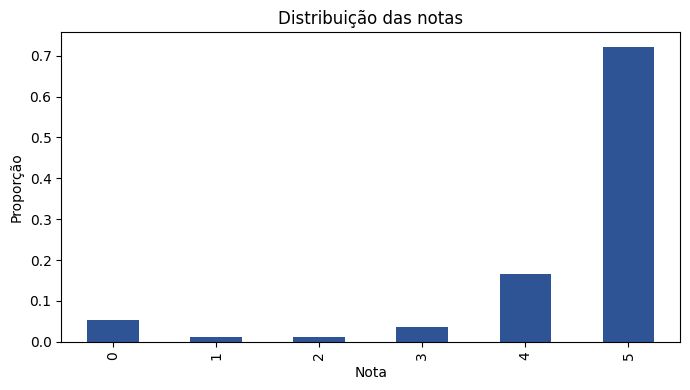

In [6]:
dist = raw_interactions["rating"].value_counts(normalize=True).sort_index()
display((dist * 100).round(2))

ax = dist.plot(kind="bar", color="#2E5496")
ax.set_title("Distribuição das notas")
ax.set_xlabel("Nota"); ax.set_ylabel("Proporção")
plt.tight_layout(); plt.show()

Mais de 72% das avaliações são nota 5, e cerca de 5,4% são nota 0 (ausência de
avaliação textual, não uma nota ruim de fato). Essa forte concentração em notas altas é o
motivo de o pipeline (`prepare_interactions`) tratar o problema como **feedback implícito**
(nota ≥ 4 vira interação positiva), em vez de tentar prever a nota exata — uma escala tão
desbalanceada dificultaria a regressão direta da nota.

## 4. Cauda longa (concentração de popularidade)

O 1% de receitas mais avaliadas concentra 23.4% das interações


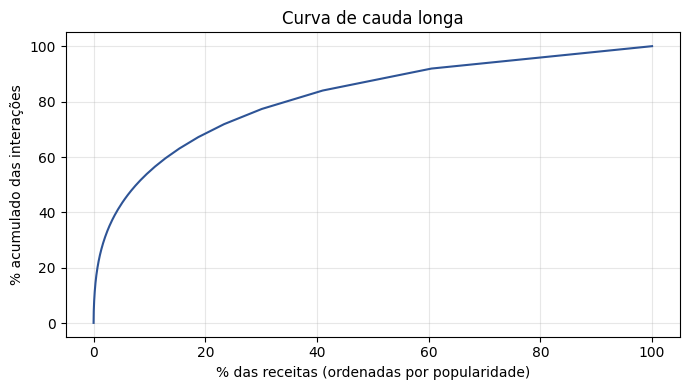

In [7]:
counts = raw_interactions["recipe_id"].value_counts().to_numpy()
share = np.cumsum(counts) / counts.sum()
top1 = int(np.ceil(0.01 * len(counts)))
print(f"O 1% de receitas mais avaliadas concentra {share[top1-1]*100:.1f}% das interações")

plt.plot(np.arange(1, len(counts)+1) / len(counts) * 100, share * 100, color="#2E5496")
plt.xlabel("% das receitas (ordenadas por popularidade)")
plt.ylabel("% acumulado das interações")
plt.title("Curva de cauda longa")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

A curva confirma o padrão de cauda longa típico de sistemas de recomendação —
poucas receitas concentram grande parte das interações, enquanto a maioria recebe poucas ou
nenhuma avaliação. Isso justifica o corte de k-core (mínimo de interações por usuário/item)
aplicado em `apply_kcore`, e explica por que a métrica de **cobertura de catálogo** é
importante na avaliação: um modelo que só recomenda os itens populares tem cobertura baixa.

## 5. Perfil nutricional das receitas

In [8]:
recipes = prepare_recipes(raw_recipes)
recipes["health_index"].describe().round(4)

count    231637.0000
mean          0.5421
std           0.1551
min           0.1250
25%           0.3750
50%           0.5000
75%           0.6250
max           1.0000
Name: health_index, dtype: float64

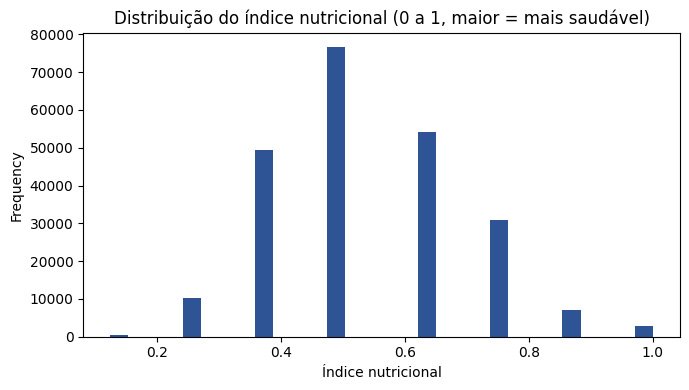

In [9]:
recipes["health_index"].plot(kind="hist", bins=30, color="#2E5496")
plt.title("Distribuição do índice nutricional (0 a 1, maior = mais saudável)")
plt.xlabel("Índice nutricional"); plt.tight_layout(); plt.show()

O índice nutricional (adaptado do semáforo nutricional FSA, ver `src/nutrition.py`)
tem média em torno de 0,54, com boa variação entre receitas — o que é necessário para que a
reordenação nutricional do sistema híbrido tenha efeito prático (se quase todas as receitas
tivessem índice parecido, reordenar por saudabilidade não mudaria muito o resultado).

## 6. Popularidade x saudabilidade — existe viés?

In [10]:
pop = raw_interactions.groupby("recipe_id").size().rename("n_avaliacoes")
merged = recipes.set_index("recipe_id").join(pop, how="inner").dropna(subset=["n_avaliacoes"])
corr = np.corrcoef(np.log1p(merged["n_avaliacoes"]), merged["health_index"])[0, 1]
print(f"Correlação entre popularidade (log) e índice nutricional: {corr:.4f}")

Correlação entre popularidade (log) e índice nutricional: -0.0192


A correlação é praticamente nula (~ -0,02), ou seja, receitas populares não são
sistematicamente mais nem menos saudáveis que as demais na base como um todo. Isso é uma boa
notícia para o projeto: a reordenação nutricional do híbrido não estará "lutando" contra um
viés estrutural forte de popularidade — o compromisso relevância×saudabilidade observado na
prova de conceito (notebook `02_poc_modelos.ipynb`) vem da forma como cada modelo pondera os
dados, não de uma correlação intrínseca da base.

## 7. Resumo da EDA

| Métrica | Valor |
|---|---|
| Receitas (bruto) | 231.637 |
| Interações (bruto) | > 1,13 milhão |
| Usuários distintos | > 226 mil |
| Notas = 0 (sem avaliação) | 5,37% |
| Notas ≥ 4 (positivas) | 88,6% |
| 1% de receitas mais populares concentra | 23,4% das interações |
| Índice nutricional médio | 0,54 |
| Correlação popularidade × saudabilidade | ≈ 0 |

Essas características (alta esparsidade, cauda longa acentuada, feedback com viés positivo)
confirmam que a base é adequada e representativa dos desafios reais da área, como já apontado
na justificativa da Etapa 1. A preparação dos dados e a prova de conceito dos modelos estão
no notebook `02_poc_modelos.ipynb`.